In [51]:
# import libraries

import math
import math as m

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

In [52]:
# load Dataset

df = pd.read_csv(r"C:\Users\Admin\Downloads\Python_Diwali_Sales_Analysis\Python_Diwali_Sales_Analysis\Diwali Sales Data.csv", encoding="latin1")
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


# UNIVARIATE ANALYSIS

In [53]:
num_cols = df.select_dtypes(include = np.number)
num_cols

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
0,1002903,28,0,1,23952.0,NaN,NaN
1,1000732,35,1,3,23934.0,NaN,NaN
2,1001990,35,1,3,23924.0,NaN,NaN
3,1001425,16,0,2,23912.0,NaN,NaN
4,1000588,28,1,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...
11246,1000695,19,1,4,370.0,NaN,NaN
11247,1004089,33,0,3,367.0,NaN,NaN
11248,1001209,40,0,4,213.0,NaN,NaN
11249,1004023,37,0,3,206.0,NaN,NaN


In [54]:
cat_cols = df.select_dtypes(include = "object")
cat_cols

,Cust_name,Product_ID,Gender,Age Group,State,Zone,Occupation,Product_Category
0,Sanskriti,P00125942,F,26-35,Maharashtra,Western,Healthcare,Auto
1,Kartik,P00110942,F,26-35,Andhra Pradesh,Southern,Govt,Auto
2,Bindu,P00118542,F,26-35,Uttar Pradesh,Central,Automobile,Auto
3,Sudevi,P00237842,M,0-17,Karnataka,Southern,Construction,Auto
4,Joni,P00057942,M,26-35,Gujarat,Western,Food Processing,Auto
...,...,...,...,...,...,...,...,...
11246,Manning,P00296942,M,18-25,Maharashtra,Western,Chemical,Office
11247,Reichenbach,P00171342,M,26-35,Haryana,Northern,Healthcare,Veterinary
11248,Oshin,P00201342,F,36-45,Madhya Pradesh,Central,Textile,Office
11249,Noonan,P00059442,M,36-45,Karnataka,Southern,Agriculture,Office


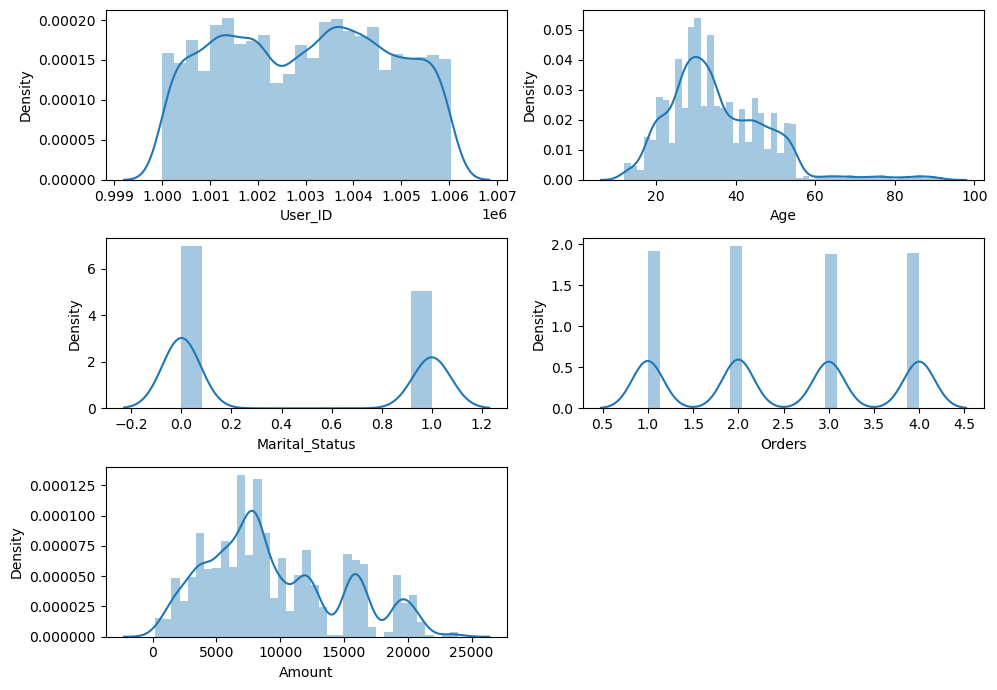

In [55]:
# numeric plot

num_cols = ['User_ID', 'Age', 'Marital_Status', 'Orders', 'Amount']

nrows = 3
ncols = 2
iterator = 1


plt.figure(figsize = (10,7))
for i in num_cols:
    plt.subplot(nrows, ncols , iterator)
    sns.distplot(df.loc[:, i])
    iterator+=1

plt.tight_layout()
plt.show()

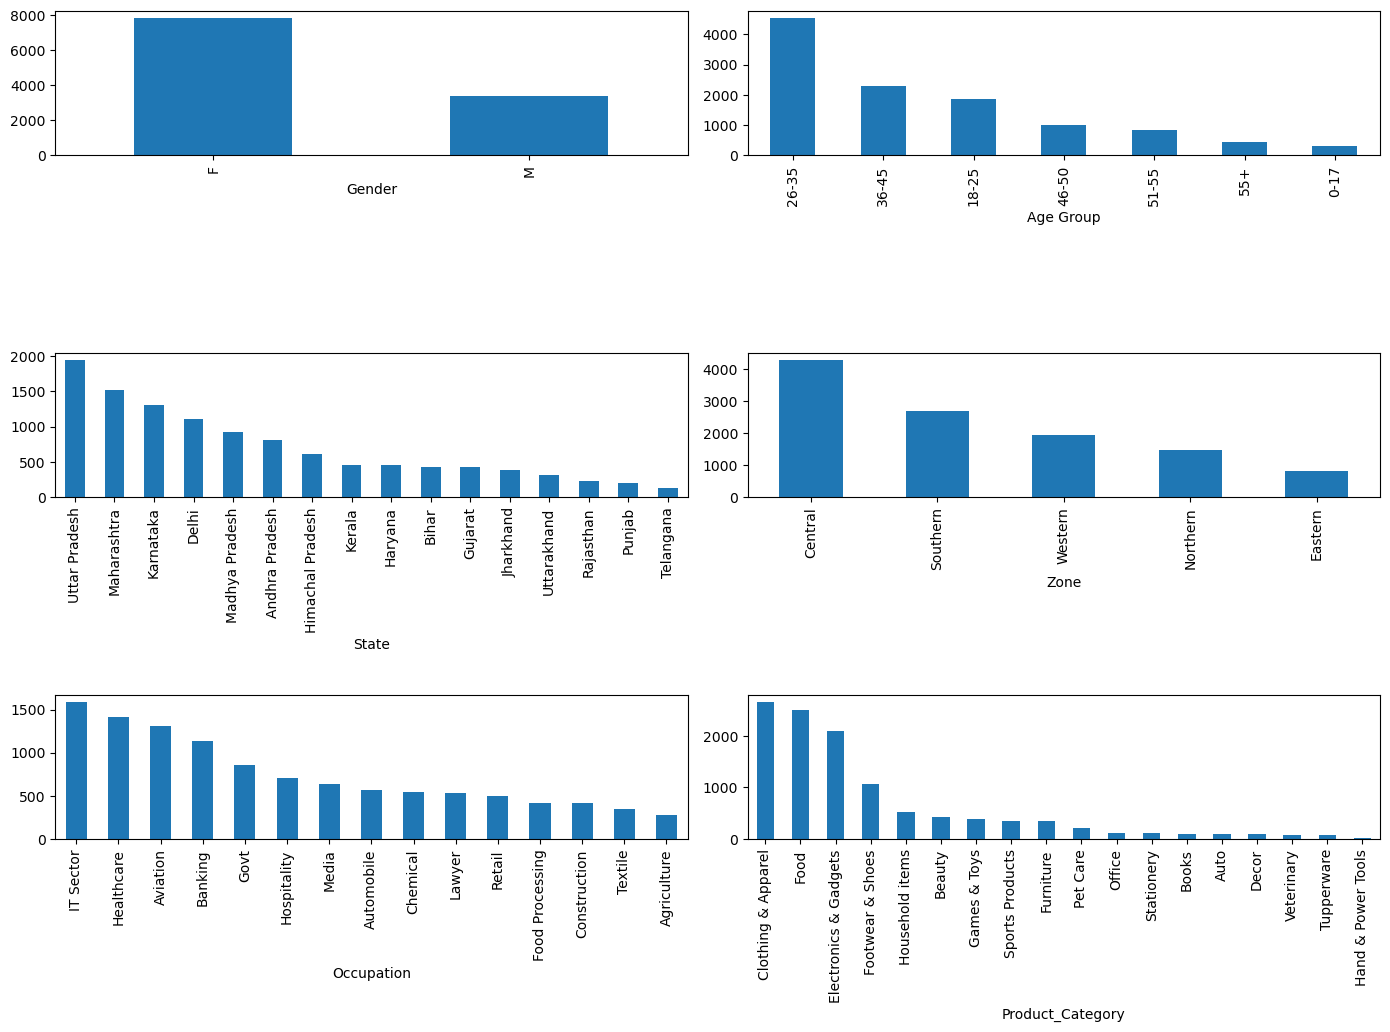

In [58]:
# categorical plot

cat_cols = ['Gender', 'Age Group', 'State', 'Zone','Occupation', 'Product_Category']

nrows = 4
ncols = 2
iterator = 1

plt.figure(figsize = (14,12))
for i in cat_cols:
    plt.subplot(nrows, ncols, iterator)
    df.loc[:,i].value_counts().plot(kind = "bar")
    iterator+=1

plt.tight_layout()
plt.show()

# BIVARIATE ANALYSIS

In [8]:
df.select_dtypes(include = np.number).columns

Index(['User_ID', 'Age', 'Marital_Status', 'Orders', 'Amount', 'Status',
       'unnamed1'],
      dtype='object')

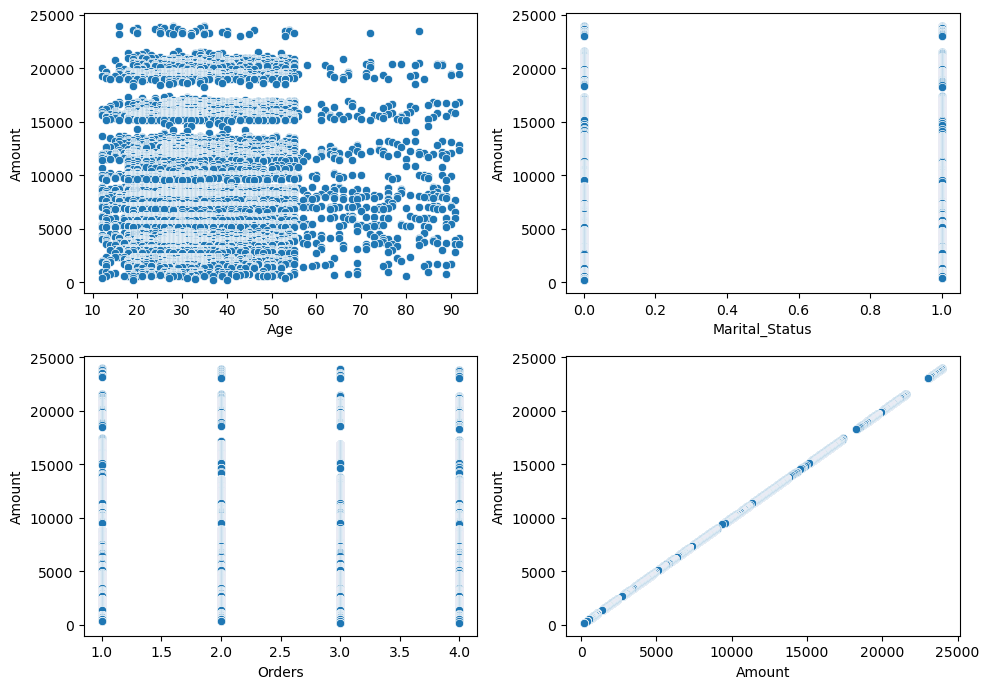

In [59]:
# num vs target
num_cols = ['Age', 'Marital_Status', 'Orders', 'Amount']

nrows = 2
ncols = 2
iterator = 1

plt.figure(figsize = (10,7))
for i in num_cols:
    plt.subplot(nrows, ncols, iterator)
    sns.scatterplot(x = df.loc[:, i], y = df['Amount'])
    iterator+=1

plt.tight_layout()
plt.show()

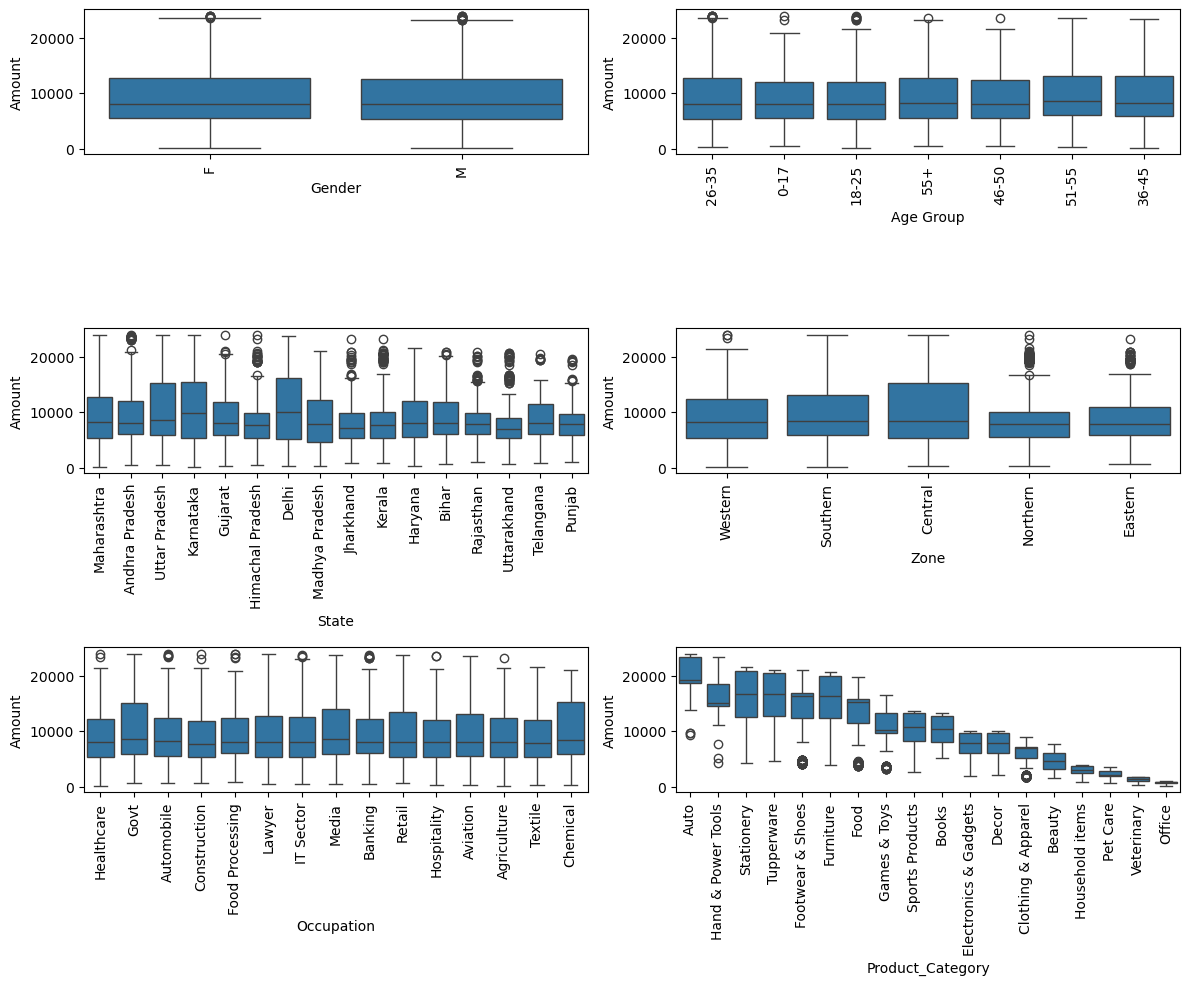

In [61]:
# cat vs target
cat_cols = ['Gender', 'Age Group', 'State', 'Zone','Occupation', 'Product_Category']

nrows = 3
ncols = 2
iterator = 1

plt.figure(figsize = (12,10))
for i in cat_cols:
    plt.subplot(nrows, ncols , iterator)
    sns.boxplot(x = df.loc[:, i], y = df["Amount"])
    plt.xticks(rotation = 90)
    iterator+=1

plt.tight_layout()
plt.show()

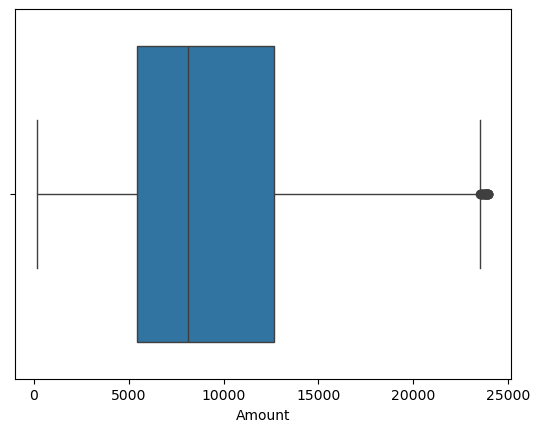

In [65]:
# target plot

sns.boxplot(x = df["Amount"])
plt.show()

# FEATURE ENGINEERING

In [12]:
df["Age Group"].unique()

array(['26-35', '0-17', '18-25', '55+', '46-50', '51-55', '36-45'],
      dtype=object)

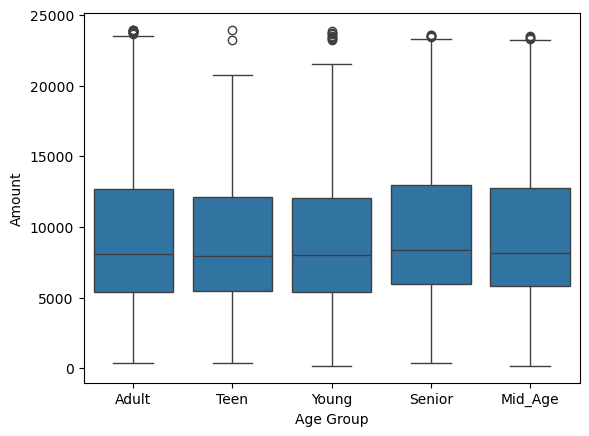

In [66]:
dict = {'0-17': "Teen", '18-25': "Young", '26-35': "Adult", '36-45':"Mid_Age", '46-50': "Mid_Age", '51-55': "Senior", '55+': "Senior"}

df["Age Group"] = df["Age Group"].map(dict)
df["Age Group"].unique()

sns.boxplot(data = df , x = "Age Group", y = "Amount")
plt.show()

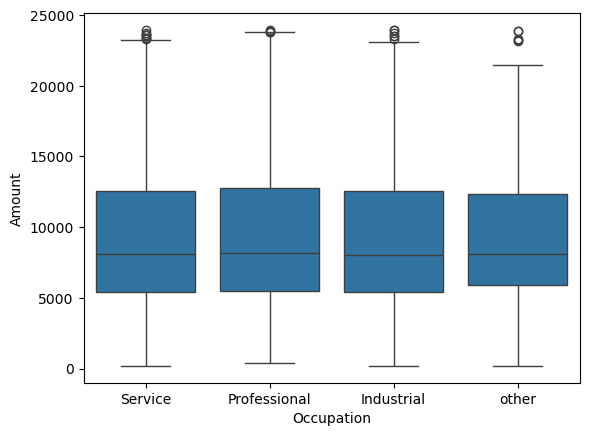

In [69]:
# Occupation

Professional = ['Lawyer', 'IT Sector', 'Media', 'Banking','Govt']
Industrial = ['Automobile', 'Construction','Chemical','Textile']
Service = ['Healthcare','Hospitality','Aviation','Retail']


def occupation(x):
    if x in Professional:
        return "Professional"
    elif x in Industrial:
        return "Industrial"
    elif x in Service:
        return "Service"
    else:
        return "other"

df["Occupation"] = df["Occupation"].apply(occupation)
df["Occupation"].unique()

sns.boxplot(data = df, x = "Occupation", y = "Amount")
plt.show()

In [15]:
df["State"].unique()

array(['Maharashtra', 'Andhra\xa0Pradesh', 'Uttar Pradesh', 'Karnataka',
       'Gujarat', 'Himachal Pradesh', 'Delhi', 'Madhya Pradesh',
       'Jharkhand', 'Kerala', 'Haryana', 'Bihar', 'Rajasthan',
       'Uttarakhand', 'Telangana', 'Punjab'], dtype=object)

In [16]:
essential = ['Food','Household items','Tupperware']
lifestyle = ['Beauty','Clothing & Apparel','Footwear & Shoes','Decor']
technical = ['Electronics & Gadgets','Auto','Hand & Power Tools']
education = ['Books','Stationery','Office']
entertainment = ['Games & Toys','Sports Products','Pet Care']


def prod_category(x):
    if x in essential:
        return "essential"
    elif x in lifestyle:
        return "lifestyle"
    elif x in technical:
        return "technical"
    elif x in education:
        return "education"
    else:
        return "entertainment"



df["Product_Category"] = df["Product_Category"].apply(prod_category)
df.Product_Category.unique()

array(['technical', 'education', 'essential', 'lifestyle',
       'entertainment'], dtype=object)

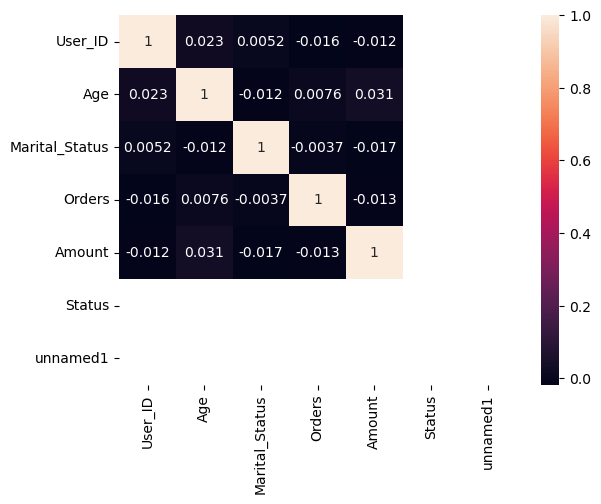

In [70]:
# correlation plot

sns.heatmap(data = df.corr(numeric_only = True), annot = True)
plt.show()

# MISSING VALUES

In [18]:
df.shape

(11251, 15)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [20]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [21]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())
df["Amount"].isnull().sum()

np.int64(0)

# Outliers Analysis and Removal

<Axes: xlabel='Amount'>

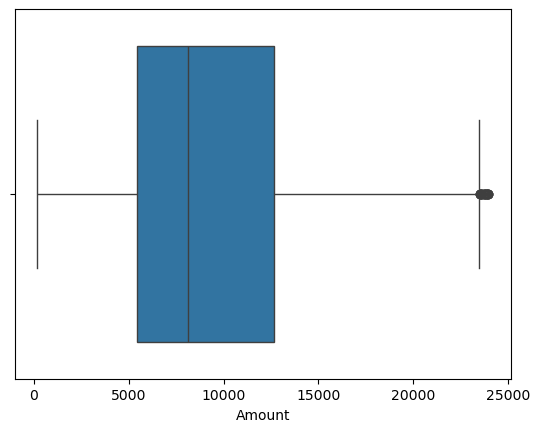

In [22]:
sns.boxplot(data = df, x = df["Amount"])

# Drop Unnecessary Columns

In [23]:
# drop that column where data is 100% null & unique values
df.drop(columns = ["User_ID","Cust_name","Product_ID","Status","unnamed1"],inplace = True)

In [24]:
df

,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,F,Adult,28,0,Maharashtra,Western,Service,technical,1,23952.0
1,F,Adult,35,1,Andhra Pradesh,Southern,Professional,technical,3,23934.0
2,F,Adult,35,1,Uttar Pradesh,Central,Industrial,technical,3,23924.0
3,M,Teen,16,0,Karnataka,Southern,Industrial,technical,2,23912.0
4,M,Adult,28,1,Gujarat,Western,other,technical,2,23877.0
...,...,...,...,...,...,...,...,...,...,...
11246,M,Young,19,1,Maharashtra,Western,Industrial,education,4,370.0
11247,M,Adult,33,0,Haryana,Northern,Service,entertainment,3,367.0
11248,F,Mid_Age,40,0,Madhya Pradesh,Central,Industrial,education,4,213.0
11249,M,Mid_Age,37,0,Karnataka,Southern,other,education,3,206.0


In [25]:
pd.get_dummies(df).shape

(11251, 41)

# Train_Test_Split

In [26]:
x = df.drop(["Amount"], axis = 1)
y = df["Amount"]

In [27]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.1,
    random_state=42
)

In [28]:
X_train.shape

(10125, 9)

In [29]:
X_test.shape

(1126, 9)

# Scalling

In [30]:
df.head()

,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,F,Adult,28,0,Maharashtra,Western,Service,technical,1,23952.0
1,F,Adult,35,1,Andhra Pradesh,Southern,Professional,technical,3,23934.0
2,F,Adult,35,1,Uttar Pradesh,Central,Industrial,technical,3,23924.0
3,M,Teen,16,0,Karnataka,Southern,Industrial,technical,2,23912.0
4,M,Adult,28,1,Gujarat,Western,other,technical,2,23877.0


In [31]:
df.loc[:, num_cols].describe()

,Age,Marital_Status,Orders,Amount
count,11251.000000,11251.000000,11251.000000,11251.000000
mean,35.421207,0.420318,2.489290,9452.176734
std,12.754122,0.493632,1.115047,5219.754408
min,12.000000,0.000000,1.000000,188.000000
25%,27.000000,0.000000,1.500000,5443.500000
50%,33.000000,0.000000,2.000000,8109.000000
75%,43.000000,1.000000,3.000000,12671.000000
max,92.000000,1.000000,4.000000,23952.000000


In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [33]:
# Numeric columns from TRAIN FEATURES
num_cols = X_train.select_dtypes(include=np.number).columns
num_cols

Index(['Age', 'Marital_Status', 'Orders'], dtype='object')

In [34]:
# Scalling on Train data
X_train[num_cols] = sc.fit_transform(X_train.loc[:, num_cols])
X_train

# y_train = sc.fit_transform(pd.DataFrame(y_train))
# y_train

,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders
10232,F,Adult,-0.342631,-0.852948,Maharashtra,Western,Service,essential,-1.334773
5250,F,Young,-1.048954,-0.852948,Jharkhand,Eastern,Professional,lifestyle,-0.435959
6462,M,Adult,-0.421112,1.172404,Madhya Pradesh,Central,Industrial,technical,0.462856
10530,F,Adult,-0.185671,-0.852948,Karnataka,Southern,other,essential,-0.435959
2874,M,Adult,-0.499592,-0.852948,Maharashtra,Western,Service,education,1.361671
...,...,...,...,...,...,...,...,...,...
5734,F,Young,-1.205914,-0.852948,Bihar,Eastern,Professional,technical,0.462856
5191,F,Mid_Age,0.913053,-0.852948,Uttarakhand,Central,Service,lifestyle,-1.334773
5390,F,Mid_Age,1.070014,-0.852948,Kerala,Southern,Industrial,essential,-1.334773
860,F,Young,-1.284395,1.172404,Bihar,Eastern,Service,essential,-0.435959


In [35]:
# Scalling on Test data

X_test[num_cols] = sc.transform(X_test.loc[:, num_cols])
X_test

,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders
5749,M,Adult,-0.421112,-0.852948,Haryana,Northern,Professional,technical,1.361671
7335,F,Adult,-0.342631,-0.852948,Uttar Pradesh,Central,Service,lifestyle,-0.435959
5932,M,Adult,-0.578072,1.172404,Uttarakhand,Central,Industrial,technical,0.462856
3819,F,Young,-1.048954,-0.852948,Karnataka,Southern,Industrial,essential,-0.435959
6395,F,Young,-1.048954,-0.852948,Rajasthan,Northern,other,technical,1.361671
...,...,...,...,...,...,...,...,...,...
5638,F,Young,-1.362875,-0.852948,Haryana,Northern,Professional,essential,-1.334773
5027,F,Adult,-0.185671,-0.852948,Jharkhand,Eastern,Service,lifestyle,0.462856
7342,F,Adult,-0.499592,-0.852948,Karnataka,Southern,Industrial,lifestyle,1.361671
5594,M,Mid_Age,1.070014,1.172404,Uttar Pradesh,Central,Service,entertainment,0.462856


# Transformation (if needed)

In [36]:
X_train.loc[:, num_cols].skew()

Age               1.187518
Marital_Status    0.319503
Orders            0.026019
dtype: float64

In [37]:
X_test.loc[:, num_cols].skew()

Age               1.147781
Marital_Status    0.354004
Orders           -0.038994
dtype: float64

In [38]:
# No need to Do Transfromation Because Data is not to much skewed

# Categorical Encoding

In [39]:
cat_cols = df.select_dtypes(include = "object")
cat_cols

,Gender,Age Group,State,Zone,Occupation,Product_Category
0,F,Adult,Maharashtra,Western,Service,technical
1,F,Adult,Andhra Pradesh,Southern,Professional,technical
2,F,Adult,Uttar Pradesh,Central,Industrial,technical
3,M,Teen,Karnataka,Southern,Industrial,technical
4,M,Adult,Gujarat,Western,other,technical
...,...,...,...,...,...,...
11246,M,Young,Maharashtra,Western,Industrial,education
11247,M,Adult,Haryana,Northern,Service,entertainment
11248,F,Mid_Age,Madhya Pradesh,Central,Industrial,education
11249,M,Mid_Age,Karnataka,Southern,other,education


In [40]:
X_train = pd.get_dummies(X_train, drop_first = True)

In [41]:
X_test = pd.get_dummies(X_test, drop_first = True)

# Modelling 

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gbm = GradientBoostingRegressor()

In [43]:
pred = gbm.fit(X_train, y_train).predict(X_test)

np.abs(pred)

array([ 7917.71181931,  7376.89866561,  7866.79453294, ...,
       10766.01659621,  9154.07287809,  8772.52612143])

In [44]:
submission = pd.DataFrame({"Actual_amount": y_test,
                           "prediction_Amount": np.abs(pred)})

In [45]:
submission

,Actual_amount,prediction_Amount
5749,8072.0,7917.711819
7335,6981.0,7376.898666
5932,8008.0,7866.794533
3819,11378.0,9570.005501
6395,7843.0,7865.117535
...,...,...
5638,8107.0,12841.925210
5027,8721.0,7146.831290
7342,6978.0,10766.016596
5594,8120.0,9154.072878


In [46]:
# submission to csv

submission.to_csv("Diwali_Sales.csv", index = False)

In [47]:
cd

C:\Users\Admin


# score evaluation

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [49]:
print("R2 Score :", r2_score(y_test, pred))

R2 Score : 0.14787018166316523


In [71]:
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE :", rmse)

RMSE : 4915.907632907604


# Summary 